<a href="https://colab.research.google.com/github/ayyanark1212-max/proj-agriii/blob/main/suiiiiiiiiiiiiii7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, log_loss

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

!pip install catboost -qq
from catboost import CatBoostClassifier

In [7]:
SEED = 42
np.random.seed(SEED)

# Load dataset
df = pd.read_csv("/content/Crop_recommendation.csv")

# Handle missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

FEATURES = ['N','P','K','ph','temperature','humidity','rainfall']
TARGET = "label"

X = df[FEATURES]
y = df[TARGET]

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

In [8]:
rf = RandomForestClassifier(n_estimators=300, random_state=SEED)

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                max_depth=3, random_state=SEED)

cb = CatBoostClassifier(iterations=500, depth=6,
                        learning_rate=0.05,
                        loss_function="MultiClass",
                        verbose=0,
                        random_seed=SEED)

stack = StackingClassifier(
    estimators=[
        ("rf", rf),
        ("gb", gb),
        ("cb", cb)
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    stack_method="predict_proba"
)

In [9]:
def evaluate_model(name, model):

    print(f"\nRunning {name}...")

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring="accuracy")

    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)

    # Training
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Inference
    start_test = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start_test

    y_proba = model.predict_proba(X_test)

    # Metrics
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average="weighted")
    test_loss = log_loss(y_test, y_proba)

    print("CV Accuracy Mean:", cv_mean)
    print("CV Accuracy Std:", cv_std)
    print("Test Accuracy:", test_acc)
    print("Test F1 Score:", test_f1)
    print("Test Log Loss:", test_loss)
    print("Training Time:", train_time)
    print("Inference Time:", inference_time)

    return {
        "model": name,
        "cv_mean": cv_mean,
        "cv_std": cv_std,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "test_loss": test_loss,
        "train_time": train_time,
        "inference_time": inference_time
    }

In [10]:
results = []

results.append(evaluate_model("Random Forest", rf))
results.append(evaluate_model("Gradient Boosting", gb))
results.append(evaluate_model("CatBoost", cb))
results.append(evaluate_model("Stacking", stack))


Running Random Forest...
CV Accuracy Mean: 0.9931818181818182
CV Accuracy Std: 0.005269101417895276
Test Accuracy: 0.9954545454545455
Test F1 Score: 0.9954517027687759
Test Log Loss: 0.054087747334085175
Training Time: 2.0069541931152344
Inference Time: 0.05273127555847168

Running Gradient Boosting...
CV Accuracy Mean: 0.9880681818181817
CV Accuracy Std: 0.0033130408493439196
Test Accuracy: 0.9886363636363636
Test F1 Score: 0.9886735002267738
Test Log Loss: 0.03396827670309828
Training Time: 21.960556268692017
Inference Time: 0.036119699478149414

Running CatBoost...
CV Accuracy Mean: 0.9897727272727274
CV Accuracy Std: 0.0077489668732874
Test Accuracy: 0.9977272727272727
Test F1 Score: 0.997725851384388
Test Log Loss: 0.02737526244012713
Training Time: 9.727991342544556
Inference Time: 0.0039446353912353516

Running Stacking...
CV Accuracy Mean: 0.9943181818181819
CV Accuracy Std: 0.004401117438872061
Test Accuracy: 0.9931818181818182
Test F1 Score: 0.9931775541531639
Test Log Loss:

In [11]:
results_df = pd.DataFrame(results)
print("\n===== MODEL COMPARISON =====")
print(results_df.sort_values(by="cv_mean", ascending=False))


===== MODEL COMPARISON =====
               model   cv_mean    cv_std  test_acc   test_f1  test_loss  \
3           Stacking  0.994318  0.004401  0.993182  0.993178   0.041814   
0      Random Forest  0.993182  0.005269  0.995455  0.995452   0.054088   
2           CatBoost  0.989773  0.007749  0.997727  0.997726   0.027375   
1  Gradient Boosting  0.988068  0.003313  0.988636  0.988674   0.033968   

   train_time  inference_time  
3  181.434426        0.140778  
0    2.006954        0.052731  
2    9.727991        0.003945  
1   21.960556        0.036120  


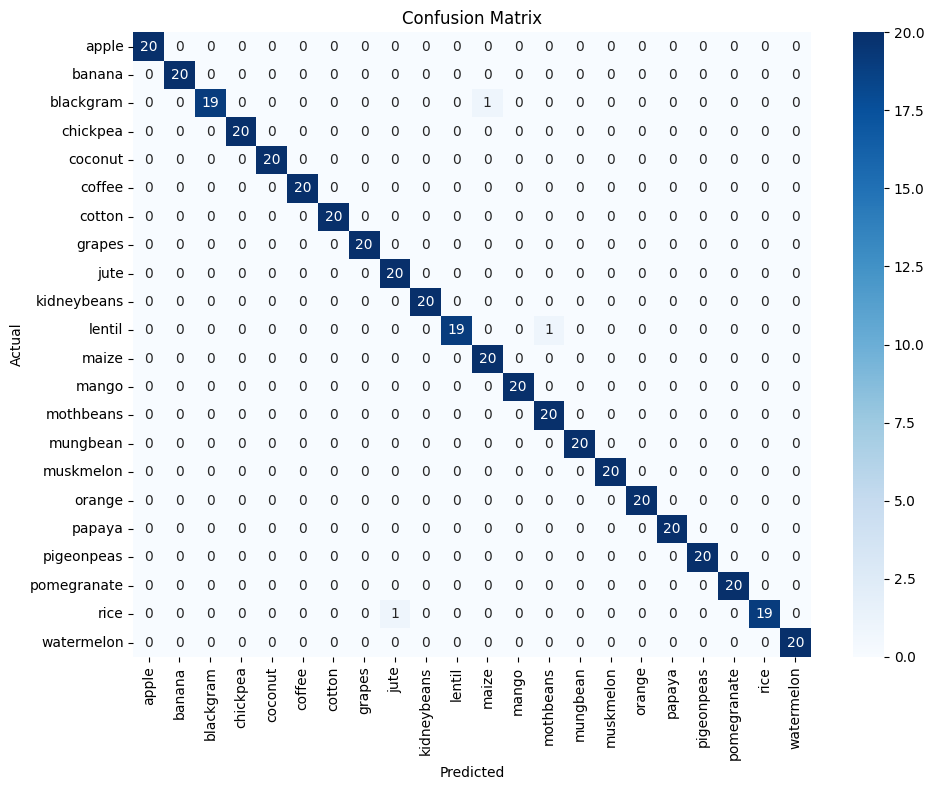

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, X_test, y_test, label_encoder):

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=300)
    plt.show()

# Example:
plot_confusion_matrix(stack, X_test, y_test, le)

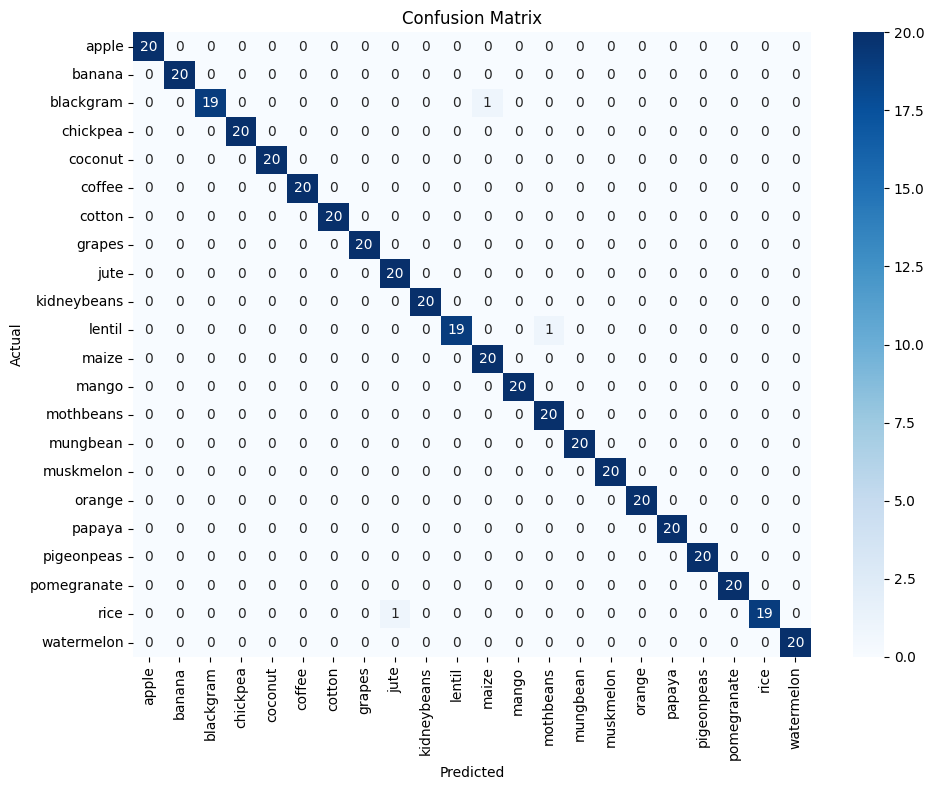

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, X_test, y_test, label_encoder):

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=300)
    plt.show()

# Example:
plot_confusion_matrix(stack, X_test, y_test, le)

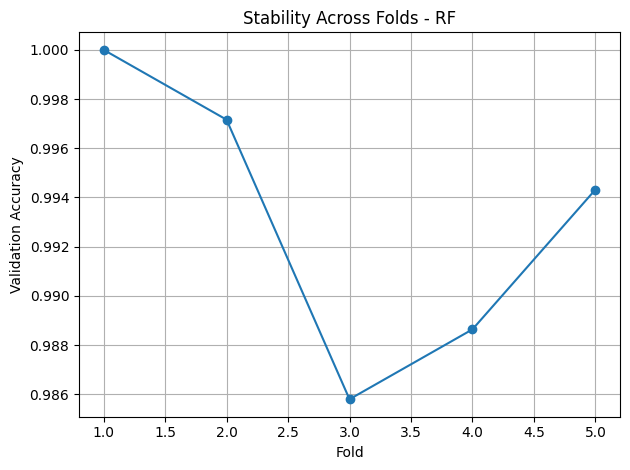

In [14]:
from sklearn.model_selection import StratifiedKFold

def stability_plot(model, X, y, name):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        model.fit(X_tr, y_tr)
        scores.append(model.score(X_val, y_val))

    plt.plot(range(1,6), scores, marker='o')
    plt.title(f"Stability Across Folds - {name}")
    plt.xlabel("Fold")
    plt.ylabel("Validation Accuracy")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"stability_{name}.png", dpi=300)
    plt.show()

stability_plot(rf, X_train, y_train, "RF")

In [15]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

def mcnemar_test(model1, model2, X_test, y_test):

    pred1 = model1.predict(X_test)
    pred2 = model2.predict(X_test)

    b = np.sum((pred1 == y_test) & (pred2 != y_test))
    c = np.sum((pred1 != y_test) & (pred2 == y_test))

    table = [[0, b],
             [c, 0]]

    result = mcnemar(table, exact=True)

    print("McNemar p-value:", result.pvalue)

# Example: RF vs Stack
mcnemar_test(rf, stack, X_test, y_test)

McNemar p-value: 1.0


In [16]:
def agent_select(results, lambda_latency=0.01, gamma_stability=0.5):

    scored = []

    for r in results:
        score = (
            r["cv_mean"]
            - gamma_stability * r["cv_std"]
            - lambda_latency * r["inference_time"]
        )
        scored.append((score, r))

    scored.sort(key=lambda x: x[0], reverse=True)

    best = scored[0][1]

    print("Selected Model:", best["model"])
    return best

best_model = agent_select(results)

Selected Model: Stacking


In [17]:
results_df = pd.DataFrame(results)

results_df["CV (Mean ± Std)"] = (
    results_df["cv_mean"].round(3).astype(str) +
    " ± " +
    results_df["cv_std"].round(3).astype(str)
)

ieee_table = results_df[[
    "model",
    "CV (Mean ± Std)",
    "test_acc",
    "test_f1",
    "test_loss",
    "train_time",
    "inference_time"
]]

print("\n===== IEEE FORMATTED TABLE =====")
print(ieee_table)


===== IEEE FORMATTED TABLE =====
               model CV (Mean ± Std)  test_acc   test_f1  test_loss  \
0      Random Forest   0.993 ± 0.005  0.995455  0.995452   0.054088   
1  Gradient Boosting   0.988 ± 0.003  0.988636  0.988674   0.033968   
2           CatBoost    0.99 ± 0.008  0.997727  0.997726   0.027375   
3           Stacking   0.994 ± 0.004  0.993182  0.993178   0.041814   

   train_time  inference_time  
0    2.006954        0.052731  
1   21.960556        0.036120  
2    9.727991        0.003945  
3  181.434426        0.140778  


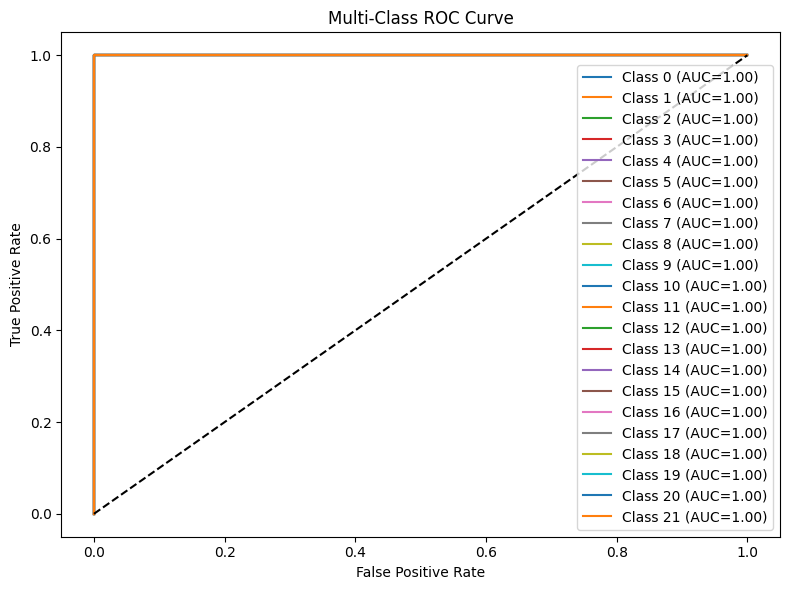

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_multiclass_roc(model, X_test, y_test):

    y_score = model.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(8,6))

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc:.2f})')

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-Class ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig("roc_curve.png", dpi=300)
    plt.show()

plot_multiclass_roc(stack, X_test, y_test)

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, log_loss
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [20]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, label_encoder):

    print(f"\n================ {name} ================")

    # -------------------------
    # 1. K-Fold Analysis
    # -------------------------
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="accuracy")

    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)
    cv_percent = (cv_std / cv_mean) * 100

    print("K-Fold Scores:", cv_scores)
    print("CV Mean:", cv_mean)
    print("CV Std:", cv_std)
    print("Coefficient of Variation (%):", cv_percent)

    # -------------------------
    # 2. Training
    # -------------------------
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # -------------------------
    # 3. Predictions
    # -------------------------
    start_test = time.time()
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    test_time = time.time() - start_test

    y_train_proba = model.predict_proba(X_train)
    y_test_proba = model.predict_proba(X_test)

    # -------------------------
    # 4. Accuracy + Loss
    # -------------------------
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_loss = log_loss(y_train, y_train_proba)
    test_loss = log_loss(y_test, y_test_proba)

    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("Train Log Loss:", train_loss)
    print("Test Log Loss:", test_loss)

    # -------------------------
    # 5. Confusion Matrix
    # -------------------------
    cm = confusion_matrix(y_test, y_test_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "CV Mean": cv_mean,
        "CV Std": cv_std,
        "CV %": cv_percent,
        "Train Acc": train_acc,
        "Test Acc": test_acc,
        "Train Loss": train_loss,
        "Test Loss": test_loss,
        "Train Time": train_time,
        "Test Time": test_time
    }


================ Random Forest ================
K-Fold Scores: [1.         0.99715909 0.98579545 0.98863636 0.99431818]
CV Mean: 0.9931818181818182
CV Std: 0.005269101417895276
Coefficient of Variation (%): 0.5305273738841926
Train Accuracy: 1.0
Test Accuracy: 0.9954545454545455
Train Log Loss: 0.017733975732736572
Test Log Loss: 0.054087747334085175


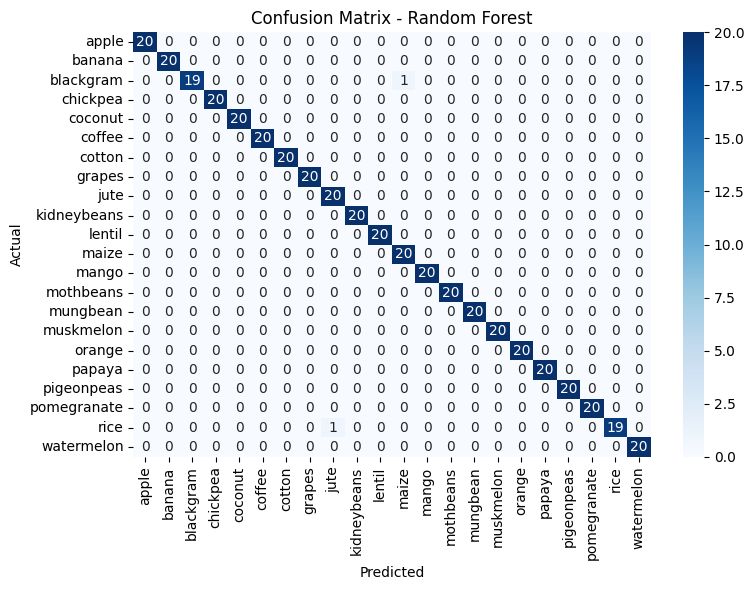


================ Gradient Boosting ================
K-Fold Scores: [0.99147727 0.98579545 0.98295455 0.99147727 0.98863636]
CV Mean: 0.9880681818181817
CV Std: 0.0033130408493439196
Coefficient of Variation (%): 0.33530488181974116
Train Accuracy: 1.0
Test Accuracy: 0.9886363636363636
Train Log Loss: 5.497274958121467e-05
Test Log Loss: 0.03396827670309828


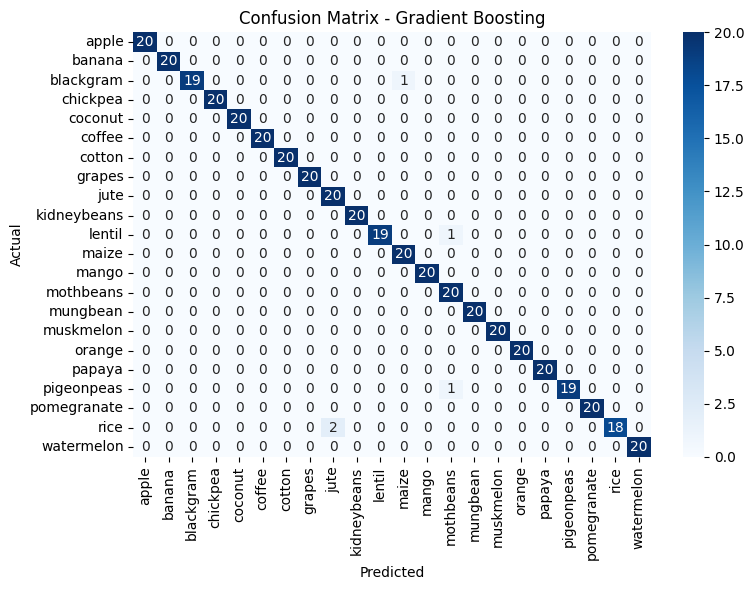


================ CatBoost ================
K-Fold Scores: [0.99147727 1.         0.97727273 0.98579545 0.99431818]
CV Mean: 0.9897727272727274
CV Std: 0.0077489668732874
Coefficient of Variation (%): 0.7829036565433883
Train Accuracy: 1.0
Test Accuracy: 0.9977272727272727
Train Log Loss: 0.014949424206340047
Test Log Loss: 0.02737526244012713


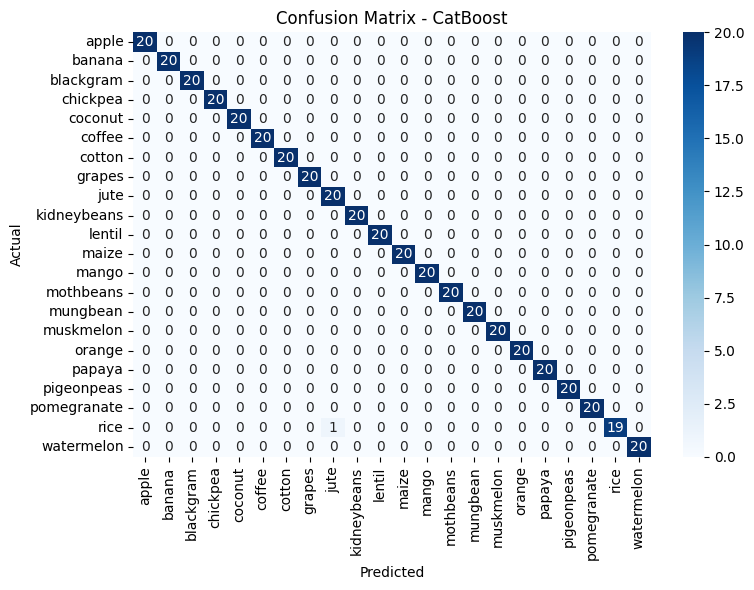


================ Stacking ================
K-Fold Scores: [0.99715909 0.99431818 0.98579545 0.99715909 0.99715909]
CV Mean: 0.9943181818181819
CV Std: 0.004401117438872061
Coefficient of Variation (%): 0.44262666813799
Train Accuracy: 1.0
Test Accuracy: 0.9931818181818182
Train Log Loss: 0.025425655493766613
Test Log Loss: 0.04181420663213035


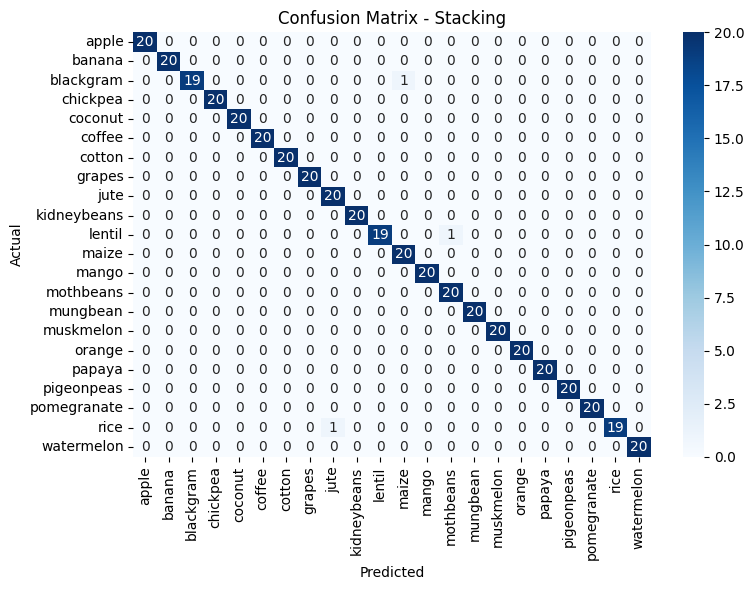

In [21]:
results = []

results.append(evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test, le))
results.append(evaluate_model("Gradient Boosting", gb, X_train, y_train, X_test, y_test, le))
results.append(evaluate_model("CatBoost", cb, X_train, y_train, X_test, y_test, le))
results.append(evaluate_model("Stacking", stack, X_train, y_train, X_test, y_test, le))

In [22]:
results_df = pd.DataFrame(results)

print("\n================ FINAL COMPARISON TABLE ================\n")
print(results_df.sort_values(by="CV Mean", ascending=False))

# Optional: Save for IEEE
results_df.to_csv("model_comparison.csv", index=False)


================ FINAL COMPARISON TABLE ================

               Model   CV Mean    CV Std      CV %  Train Acc  Test Acc  \
3           Stacking  0.994318  0.004401  0.442627        1.0  0.993182   
0      Random Forest  0.993182  0.005269  0.530527        1.0  0.995455   
2           CatBoost  0.989773  0.007749  0.782904        1.0  0.997727   
1  Gradient Boosting  0.988068  0.003313  0.335305        1.0  0.988636   

   Train Loss  Test Loss  Train Time  Test Time  
3    0.025426   0.041814  183.823348   0.390820  
0    0.017734   0.054088    0.998755   0.083661  
2    0.014949   0.027375   10.659714   0.016891  
1    0.000055   0.033968   24.259482   0.158477  


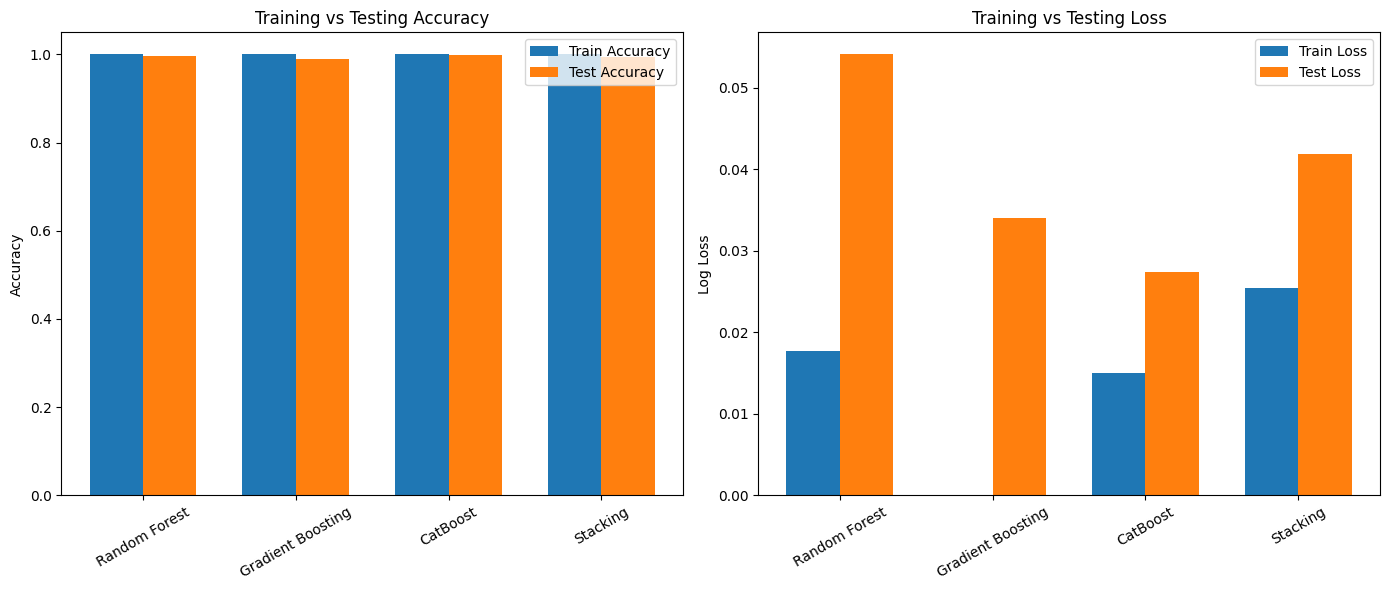

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_accuracy_loss(results_df):

    models = results_df["Model"]

    train_acc = results_df["Train Acc"]
    test_acc = results_df["Test Acc"]

    train_loss = results_df["Train Loss"]
    test_loss = results_df["Test Loss"]

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(1, 2, figsize=(14,6))

    # ---------------- Accuracy Plot ----------------
    ax[0].bar(x - width/2, train_acc, width, label='Train Accuracy')
    ax[0].bar(x + width/2, test_acc, width, label='Test Accuracy')

    ax[0].set_ylabel('Accuracy')
    ax[0].set_title('Training vs Testing Accuracy')
    ax[0].set_xticks(x)
    ax[0].set_xticklabels(models, rotation=30)
    ax[0].legend()

    # ---------------- Loss Plot ----------------
    ax[1].bar(x - width/2, train_loss, width, label='Train Loss')
    ax[1].bar(x + width/2, test_loss, width, label='Test Loss')

    ax[1].set_ylabel('Log Loss')
    ax[1].set_title('Training vs Testing Loss')
    ax[1].set_xticks(x)
    ax[1].set_xticklabels(models, rotation=30)
    ax[1].legend()

    plt.tight_layout()
    plt.savefig("accuracy_loss_comparison.png", dpi=300)
    plt.show()

# Call function
plot_accuracy_loss(results_df)

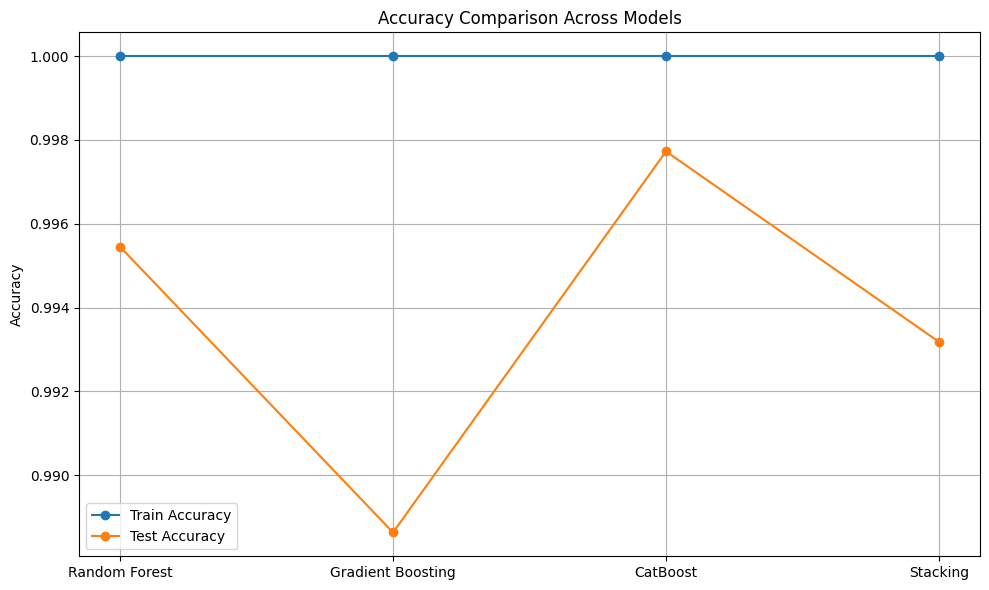

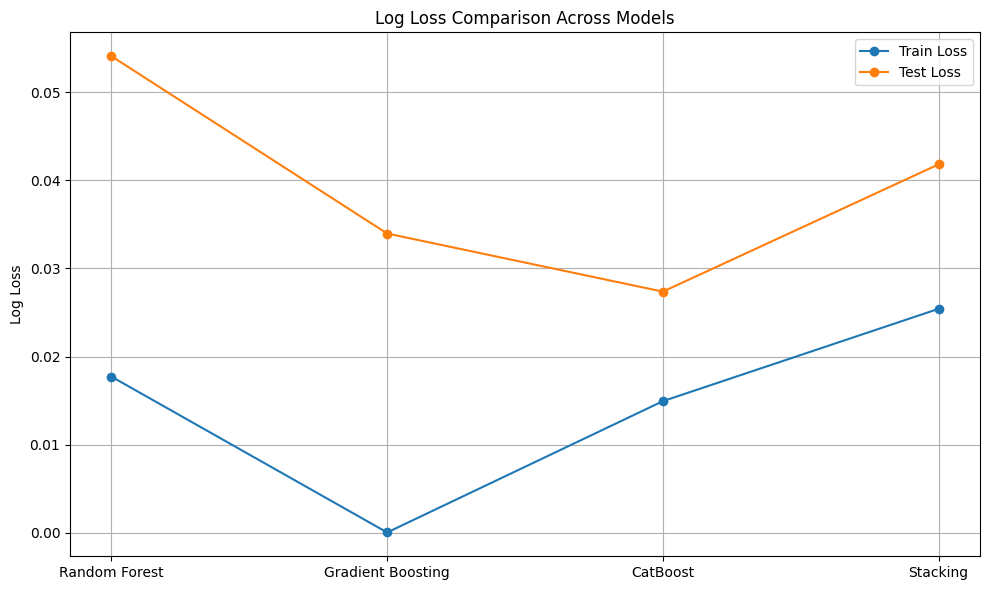

In [24]:
def plot_line_accuracy_loss(results_df):

    models = results_df["Model"]

    plt.figure(figsize=(10,6))
    plt.plot(models, results_df["Train Acc"], marker='o', label="Train Accuracy")
    plt.plot(models, results_df["Test Acc"], marker='o', label="Test Accuracy")
    plt.title("Accuracy Comparison Across Models")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("accuracy_line_plot.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10,6))
    plt.plot(models, results_df["Train Loss"], marker='o', label="Train Loss")
    plt.plot(models, results_df["Test Loss"], marker='o', label="Test Loss")
    plt.title("Log Loss Comparison Across Models")
    plt.ylabel("Log Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("loss_line_plot.png", dpi=300)
    plt.show()

plot_line_accuracy_loss(results_df)

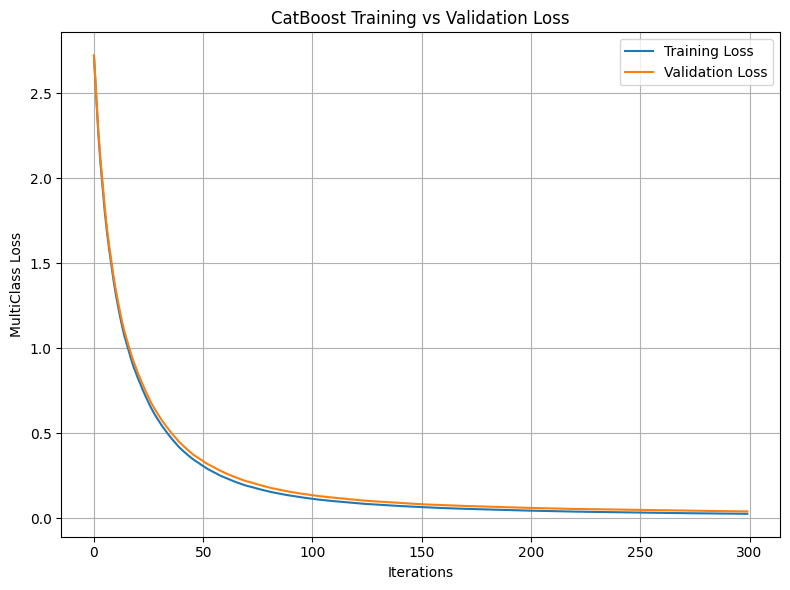

In [25]:
# Retrain CatBoost with evaluation set
cb_iter = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    verbose=False,
    random_seed=42
)

cb_iter.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

evals = cb_iter.get_evals_result()

train_loss_curve = evals['learn']['MultiClass']
val_loss_curve = evals['validation']['MultiClass']

plt.figure(figsize=(8,6))
plt.plot(train_loss_curve, label="Training Loss")
plt.plot(val_loss_curve, label="Validation Loss")
plt.xlabel("Iterations")
plt.ylabel("MultiClass Loss")
plt.title("CatBoost Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("catboost_iteration_loss.png", dpi=300)
plt.show()

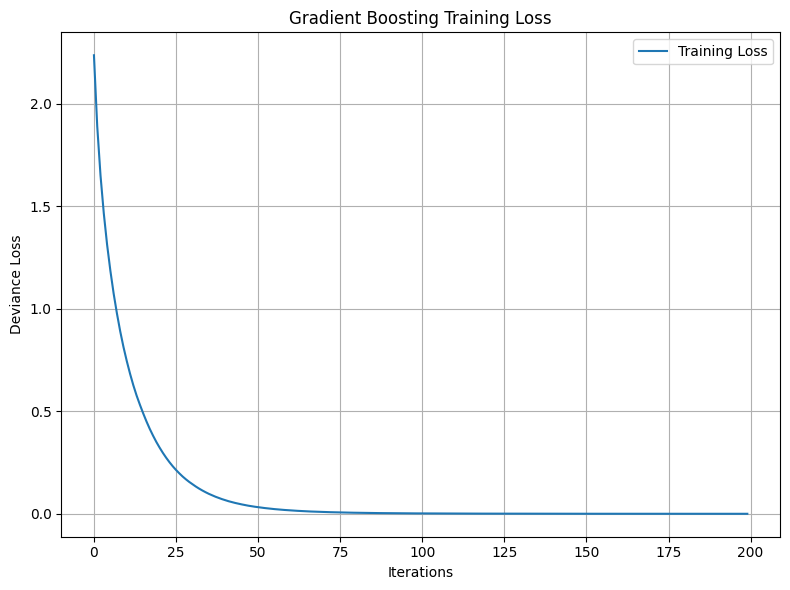

In [26]:
from sklearn.ensemble import GradientBoostingClassifier

gb_iter = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb_iter.fit(X_train, y_train)

plt.figure(figsize=(8,6))
plt.plot(gb_iter.train_score_, label="Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Deviance Loss")
plt.title("Gradient Boosting Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gb_iteration_loss.png", dpi=300)
plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define multiple seeds
seeds = [0, 10, 21, 42, 55, 77, 100, 123, 200, 500]

rf_seed_results = []

In [28]:
for s in seeds:

    rf_model = RandomForestClassifier(
        n_estimators=300,
        random_state=s
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)

    cv_scores = cross_val_score(
        rf_model,
        X_train,
        y_train,
        cv=skf,
        scoring="accuracy"
    )

    mean_acc = np.mean(cv_scores)

    rf_seed_results.append(mean_acc)

    print(f"Seed {s} -> CV Accuracy: {mean_acc:.4f}")

Seed 0 -> CV Accuracy: 0.9960
Seed 10 -> CV Accuracy: 0.9938
Seed 21 -> CV Accuracy: 0.9955
Seed 42 -> CV Accuracy: 0.9932
Seed 55 -> CV Accuracy: 0.9960
Seed 77 -> CV Accuracy: 0.9938
Seed 100 -> CV Accuracy: 0.9960
Seed 123 -> CV Accuracy: 0.9966
Seed 200 -> CV Accuracy: 0.9960
Seed 500 -> CV Accuracy: 0.9932


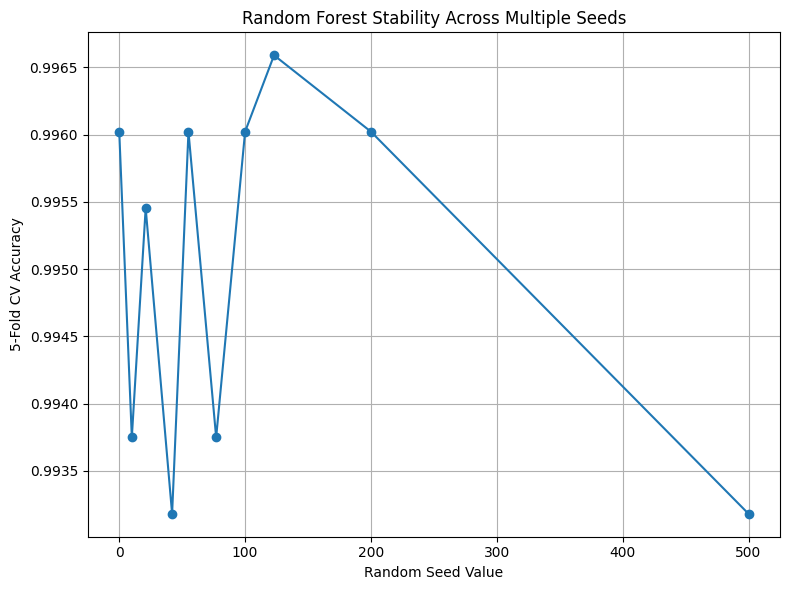

In [29]:
plt.figure(figsize=(8,6))

plt.plot(seeds, rf_seed_results, marker='o', linestyle='-')
plt.xlabel("Random Seed Value")
plt.ylabel("5-Fold CV Accuracy")
plt.title("Random Forest Stability Across Multiple Seeds")
plt.grid(True)

plt.tight_layout()
plt.savefig("rf_seed_vs_accuracy.png", dpi=300)
plt.show()

In [30]:
mean_seed_acc = np.mean(rf_seed_results)
std_seed_acc = np.std(rf_seed_results)
cv_percent = (std_seed_acc / mean_seed_acc) * 100

print("\n===== MULTI-SEED ANALYSIS =====")
print("Mean Accuracy Across Seeds:", mean_seed_acc)
print("Standard Deviation:", std_seed_acc)
print("Coefficient of Variation (%):", cv_percent)


===== MULTI-SEED ANALYSIS =====
Mean Accuracy Across Seeds: 0.9949999999999999
Standard Deviation: 0.0012906609876818347
Coefficient of Variation (%): 0.12971467212882762


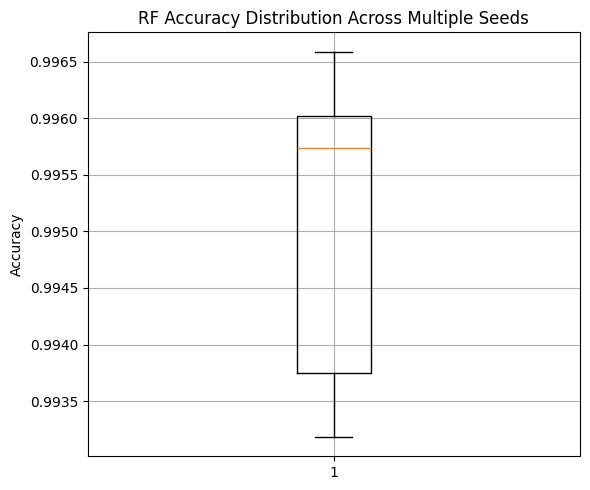

In [31]:
plt.figure(figsize=(6,5))

plt.boxplot(rf_seed_results)
plt.ylabel("Accuracy")
plt.title("RF Accuracy Distribution Across Multiple Seeds")
plt.grid(True)

plt.tight_layout()
plt.savefig("rf_seed_boxplot.png", dpi=300)
plt.show()

In [32]:
from sklearn.model_selection import RepeatedStratifiedKFold

rkf = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)

scores = cross_val_score(rf_model, X_train, y_train, cv=rkf)

print("Repeated CV Mean:", np.mean(scores))
print("Repeated CV Std:", np.std(scores))

Repeated CV Mean: 0.9948295454545456
Repeated CV Std: 0.003534163986382732


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier

seeds = [0, 10, 21, 42, 55, 77, 100, 123, 200, 500]

In [34]:
def multi_seed_analysis(model_type, model_name):

    seed_accuracies = []

    for s in seeds:

        if model_type == "RF":
            model = RandomForestClassifier(
                n_estimators=300,
                random_state=s
            )

        elif model_type == "GB":
            model = GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                random_state=s
            )

        elif model_type == "CB":
            model = CatBoostClassifier(
                iterations=500,
                depth=6,
                learning_rate=0.05,
                loss_function="MultiClass",
                verbose=0,
                random_seed=s
            )

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)

        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=skf,
            scoring="accuracy"
        )

        mean_acc = np.mean(cv_scores)
        seed_accuracies.append(mean_acc)

        print(f"{model_name} | Seed {s} → {mean_acc:.4f}")

    return seed_accuracies

In [35]:
rf_results = multi_seed_analysis("RF", "Random Forest")
gb_results = multi_seed_analysis("GB", "Gradient Boosting")
cb_results = multi_seed_analysis("CB", "CatBoost")

Random Forest | Seed 0 → 0.9960
Random Forest | Seed 10 → 0.9938
Random Forest | Seed 21 → 0.9955
Random Forest | Seed 42 → 0.9932
Random Forest | Seed 55 → 0.9960
Random Forest | Seed 77 → 0.9938
Random Forest | Seed 100 → 0.9960
Random Forest | Seed 123 → 0.9966
Random Forest | Seed 200 → 0.9960
Random Forest | Seed 500 → 0.9932
Gradient Boosting | Seed 0 → 0.9903
Gradient Boosting | Seed 10 → 0.9858
Gradient Boosting | Seed 21 → 0.9881
Gradient Boosting | Seed 42 → 0.9881
Gradient Boosting | Seed 55 → 0.9886
Gradient Boosting | Seed 77 → 0.9852
Gradient Boosting | Seed 100 → 0.9864
Gradient Boosting | Seed 123 → 0.9852
Gradient Boosting | Seed 200 → 0.9847
Gradient Boosting | Seed 500 → 0.9847
CatBoost | Seed 0 → 0.9955
CatBoost | Seed 10 → 0.9932
CatBoost | Seed 21 → 0.9909
CatBoost | Seed 42 → 0.9898
CatBoost | Seed 55 → 0.9966
CatBoost | Seed 77 → 0.9926
CatBoost | Seed 100 → 0.9926
CatBoost | Seed 123 → 0.9920
CatBoost | Seed 200 → 0.9926
CatBoost | Seed 500 → 0.9932


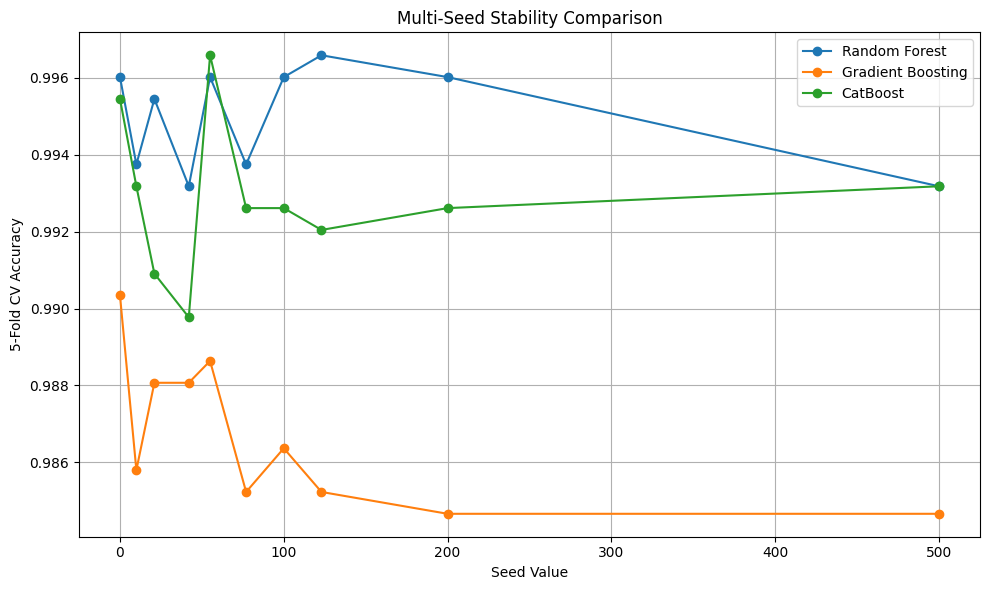

In [36]:
plt.figure(figsize=(10,6))

plt.plot(seeds, rf_results, marker='o', label="Random Forest")
plt.plot(seeds, gb_results, marker='o', label="Gradient Boosting")
plt.plot(seeds, cb_results, marker='o', label="CatBoost")

plt.xlabel("Seed Value")
plt.ylabel("5-Fold CV Accuracy")
plt.title("Multi-Seed Stability Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("multi_seed_comparison.png", dpi=300)
plt.show()

In [37]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "CatBoost"],
    "Mean Accuracy": [
        np.mean(rf_results),
        np.mean(gb_results),
        np.mean(cb_results)
    ],
    "Std Deviation": [
        np.std(rf_results),
        np.std(gb_results),
        np.std(cb_results)
    ]
})

comparison["CV (%)"] = (
    comparison["Std Deviation"] /
    comparison["Mean Accuracy"]
) * 100

print("\n===== MULTI-SEED STABILITY TABLE =====")
print(comparison)


===== MULTI-SEED STABILITY TABLE =====
               Model  Mean Accuracy  Std Deviation    CV (%)
0      Random Forest       0.995000       0.001291  0.129715
1  Gradient Boosting       0.986705       0.001853  0.187833
2           CatBoost       0.992898       0.001872  0.188494


/tmp/ipykernel_275/987862875.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


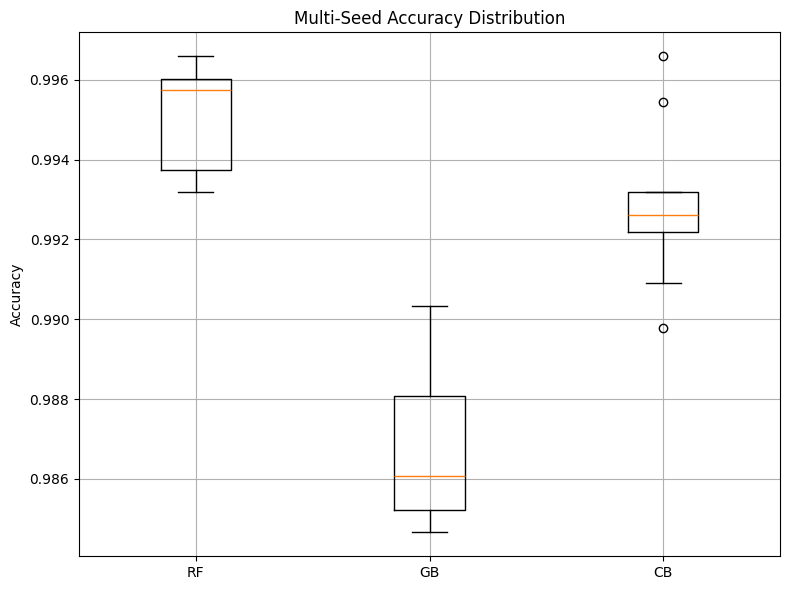

In [38]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [rf_results, gb_results, cb_results],
    labels=["RF", "GB", "CB"]
)

plt.ylabel("Accuracy")
plt.title("Multi-Seed Accuracy Distribution")
plt.grid(True)

plt.tight_layout()
plt.savefig("multi_seed_boxplot.png", dpi=300)
plt.show()

In [39]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

In [40]:
def evaluate_scaling(model, model_name):

    scalers = {
        "No Scaling": None,
        "MinMax": MinMaxScaler(),
        "Standard": StandardScaler(),
        "Normalizer": Normalizer()
    }

    scaling_results = {}

    for scaler_name, scaler in scalers.items():

        if scaler is not None:
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
        else:
            X_train_scaled = X_train
            X_test_scaled = X_test

        model.fit(X_train_scaled, y_train)
        acc = model.score(X_test_scaled, y_test)

        scaling_results[scaler_name] = acc
        print(f"{model_name} - {scaler_name} Accuracy: {acc:.4f}")

    return scaling_results

In [41]:
rf_scaling = evaluate_scaling(rf, "RF")
gb_scaling = evaluate_scaling(gb, "GB")
cb_scaling = evaluate_scaling(cb, "CB")

RF - No Scaling Accuracy: 0.9955
RF - MinMax Accuracy: 0.9955
RF - Standard Accuracy: 0.9955
RF - Normalizer Accuracy: 0.9705
GB - No Scaling Accuracy: 0.9886
GB - MinMax Accuracy: 0.9886
GB - Standard Accuracy: 0.9864
GB - Normalizer Accuracy: 0.9591
CB - No Scaling Accuracy: 0.9977
CB - MinMax Accuracy: 0.9977
CB - Standard Accuracy: 0.9977
CB - Normalizer Accuracy: 0.9773


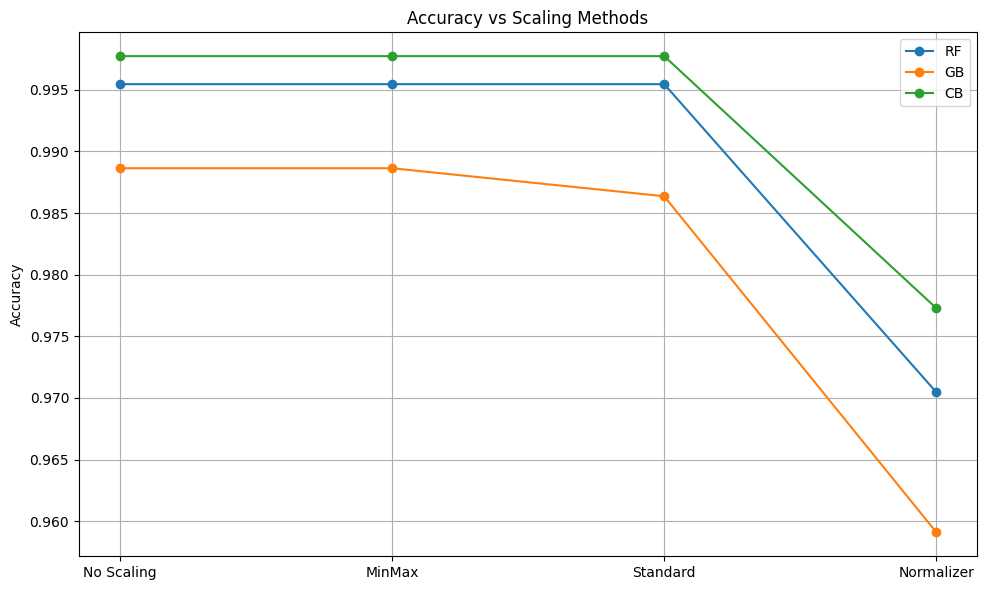

In [42]:
import matplotlib.pyplot as plt
import numpy as np

def plot_scaling_comparison(rf_scaling, gb_scaling, cb_scaling):

    labels = list(rf_scaling.keys())
    x = np.arange(len(labels))

    plt.figure(figsize=(10,6))

    plt.plot(x, list(rf_scaling.values()), marker='o', label="RF")
    plt.plot(x, list(gb_scaling.values()), marker='o', label="GB")
    plt.plot(x, list(cb_scaling.values()), marker='o', label="CB")

    plt.xticks(x, labels)
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Scaling Methods")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_scaling_comparison(rf_scaling, gb_scaling, cb_scaling)

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

y_train_nn = to_categorical(y_train)
y_test_nn = to_categorical(y_test)

In [44]:
def evaluate_activation(activation):

    model = Sequential()
    model.add(Dense(32, activation=activation, input_shape=(X_train.shape[1],)))
    model.add(Dense(16, activation=activation))
    model.add(Dense(y_train_nn.shape[1], activation='softmax'))

    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train_nn,
        epochs=50,
        batch_size=32,
        verbose=0,
        validation_data=(X_test, y_test_nn)
    )

    test_loss, test_acc = model.evaluate(X_test, y_test_nn, verbose=0)

    return test_acc

In [45]:
activations = ["relu", "sigmoid", "tanh"]

activation_results = {}

for act in activations:
    acc = evaluate_activation(act)
    activation_results[act] = acc
    print(f"Activation {act} Accuracy: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Activation relu Accuracy: 0.9545
Activation sigmoid Accuracy: 0.7432
Activation tanh Accuracy: 0.9591


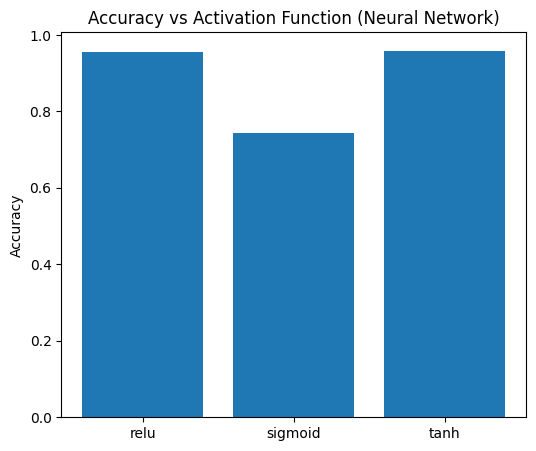

In [46]:
plt.figure(figsize=(6,5))
plt.bar(activation_results.keys(), activation_results.values())
plt.ylabel("Accuracy")
plt.title("Accuracy vs Activation Function (Neural Network)")
plt.show()

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss
import time

rf = RandomForestClassifier(n_estimators=300, random_state=42)

start = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start

rf_train_acc = rf.score(X_train, y_train)
rf_test_acc = rf.score(X_test, y_test)

rf_train_loss = log_loss(y_train, rf.predict_proba(X_train))
rf_test_loss = log_loss(y_test, rf.predict_proba(X_test))

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import numpy as np

y_train_nn = to_categorical(y_train)
y_test_nn = to_categorical(y_test)

def train_nn(activation):

    model = Sequential()
    model.add(Dense(64, activation=activation, input_shape=(X_train.shape[1],)))
    model.add(Dense(32, activation=activation))
    model.add(Dense(y_train_nn.shape[1], activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train_nn,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test_nn),
        verbose=0
    )

    test_loss, test_acc = model.evaluate(X_test, y_test_nn, verbose=0)

    return model, history, test_acc, test_loss

In [49]:
activations = ["relu", "sigmoid", "tanh"]

nn_results = {}

for act in activations:
    model, history, acc, loss = train_nn(act)
    nn_results[act] = {
        "model": model,
        "history": history,
        "test_acc": acc,
        "test_loss": loss
    }
    print(f"{act} Test Accuracy: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


relu Test Accuracy: 0.9682
sigmoid Test Accuracy: 0.8636
tanh Test Accuracy: 0.9864


In [50]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Model": ["Random Forest", "NN-ReLU", "NN-Sigmoid", "NN-Tanh"],
    "Test Accuracy": [
        rf_test_acc,
        nn_results["relu"]["test_acc"],
        nn_results["sigmoid"]["test_acc"],
        nn_results["tanh"]["test_acc"]
    ],
    "Test Loss": [
        rf_test_loss,
        nn_results["relu"]["test_loss"],
        nn_results["sigmoid"]["test_loss"],
        nn_results["tanh"]["test_loss"]
    ]
})

print("\n===== COMPARISON TABLE =====")
print(comparison_table)

# LaTeX version for IEEE
print("\nLaTeX Table:")
print(comparison_table.to_latex(index=False))


===== COMPARISON TABLE =====
           Model  Test Accuracy  Test Loss
0  Random Forest       0.995455   0.054088
1        NN-ReLU       0.968182   0.100268
2     NN-Sigmoid       0.863636   0.804842
3        NN-Tanh       0.986364   0.077522

LaTeX Table:
\begin{tabular}{lrr}
\toprule
Model & Test Accuracy & Test Loss \\
\midrule
Random Forest & 0.995455 & 0.054088 \\
NN-ReLU & 0.968182 & 0.100268 \\
NN-Sigmoid & 0.863636 & 0.804842 \\
NN-Tanh & 0.986364 & 0.077522 \\
\bottomrule
\end{tabular}



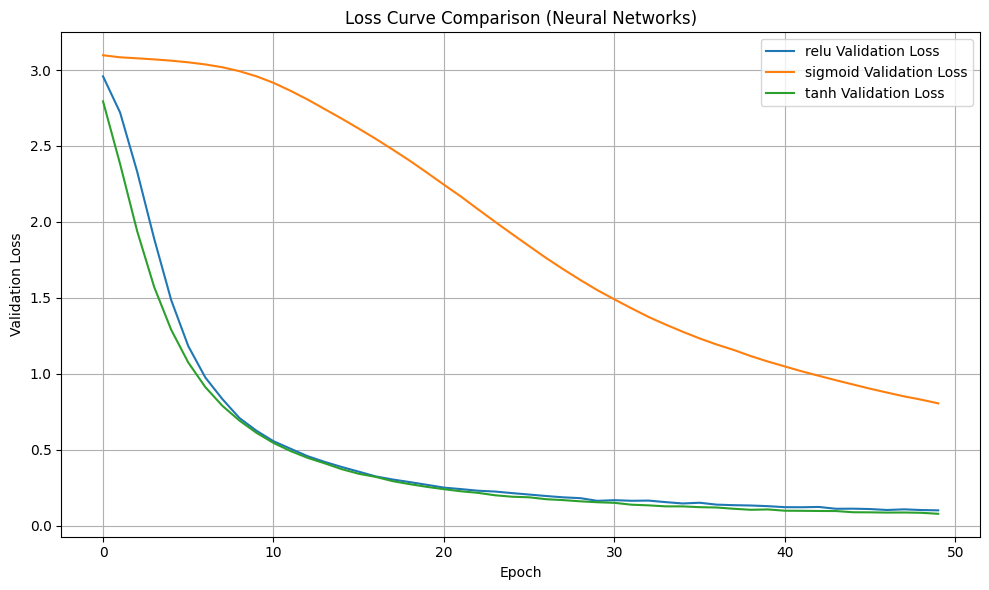

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for act in activations:
    plt.plot(
        nn_results[act]["history"].history["val_loss"],
        label=f"{act} Validation Loss"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Loss Curve Comparison (Neural Networks)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("nn_loss_comparison.png", dpi=300)
plt.show()

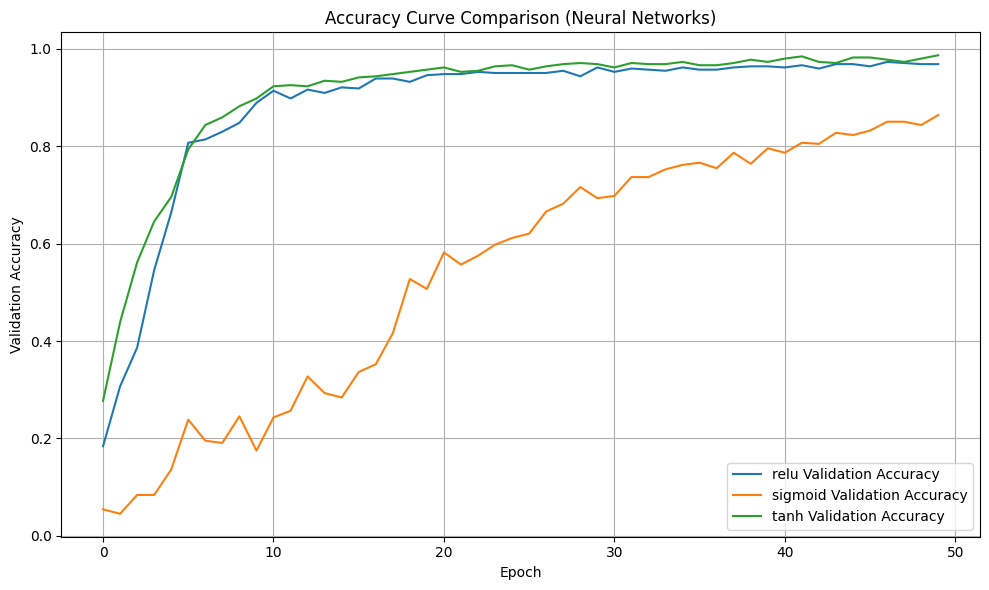

In [52]:
plt.figure(figsize=(10,6))

for act in activations:
    plt.plot(
        nn_results[act]["history"].history["val_accuracy"],
        label=f"{act} Validation Accuracy"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy Curve Comparison (Neural Networks)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("nn_accuracy_comparison.png", dpi=300)
plt.show()

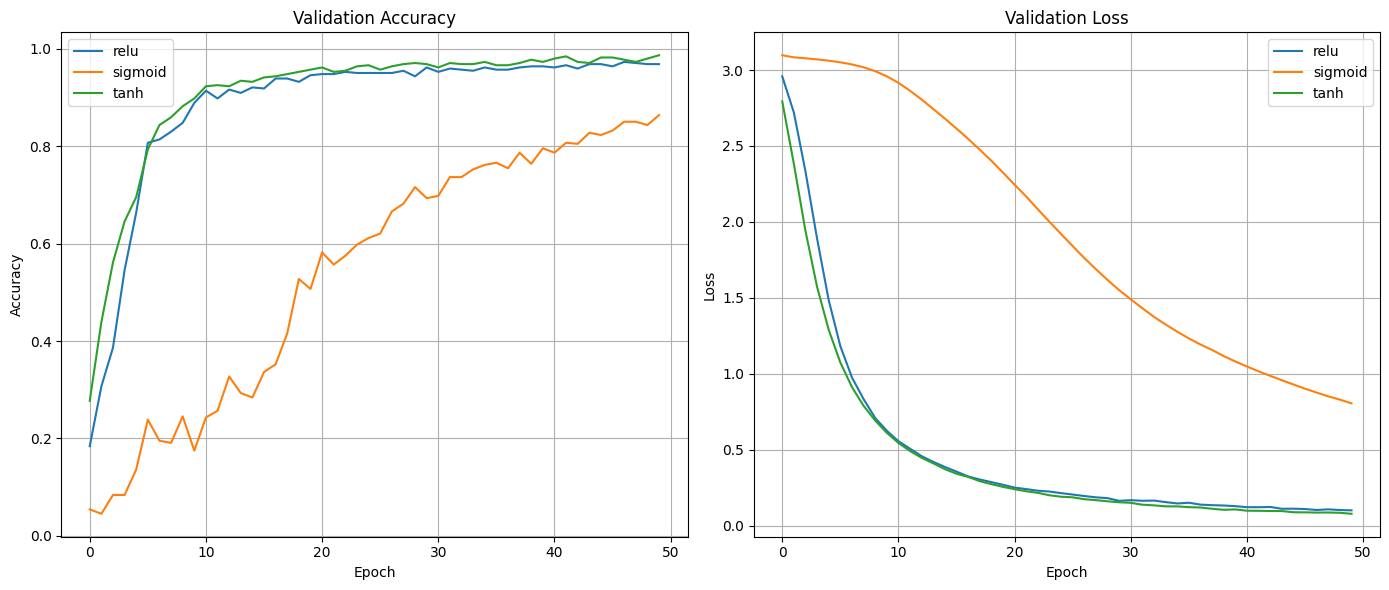

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))

# Accuracy curves
for act in activations:
    ax[0].plot(
        nn_results[act]["history"].history["val_accuracy"],
        label=act
    )

ax[0].set_title("Validation Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].grid(True)

# Loss curves
for act in activations:
    ax[1].plot(
        nn_results[act]["history"].history["val_loss"],
        label=act
    )

ax[1].set_title("Validation Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.savefig("ieee_combined_figure.png", dpi=300)
plt.show()

In [54]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2b7821c6be01be641ff525cde15298d5c8fb2ac1d3c6e42f8b648632b0cf16c5
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [55]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

In [56]:
feature_names = FEATURES
class_names = le.classes_

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

In [57]:
def run_lime(model, model_name, sample_index=0):

    print(f"\nGenerating LIME for {model_name}...")

    sample = X_test[sample_index]

    exp = explainer.explain_instance(
        data_row=sample,
        predict_fn=model.predict_proba,
        num_features=8
    )

    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation - {model_name}")
    plt.tight_layout()
    plt.savefig(f"lime_{model_name}.png", dpi=300)
    plt.show()


Generating LIME for RandomForest...


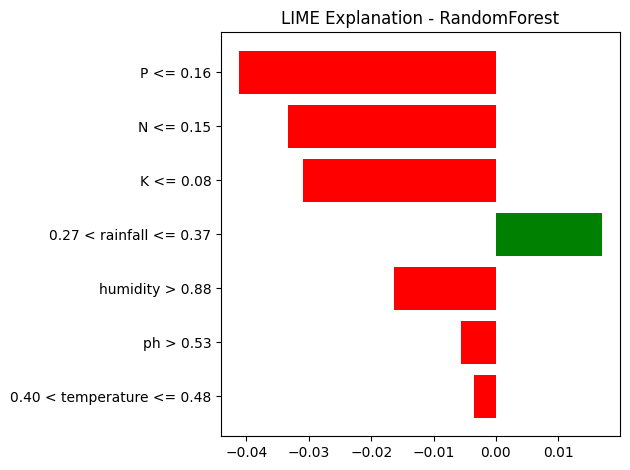


Generating LIME for GradientBoosting...


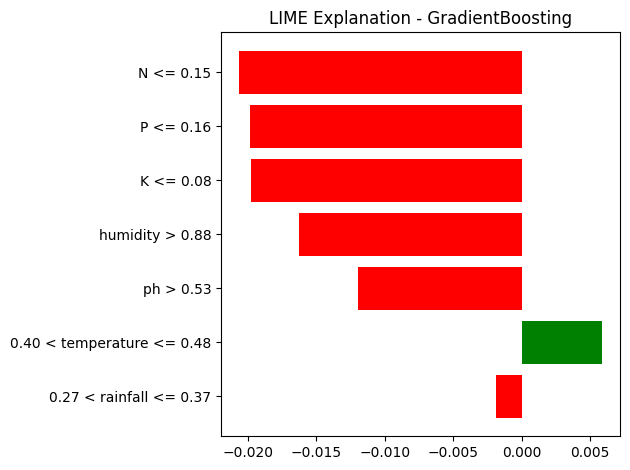


Generating LIME for CatBoost...


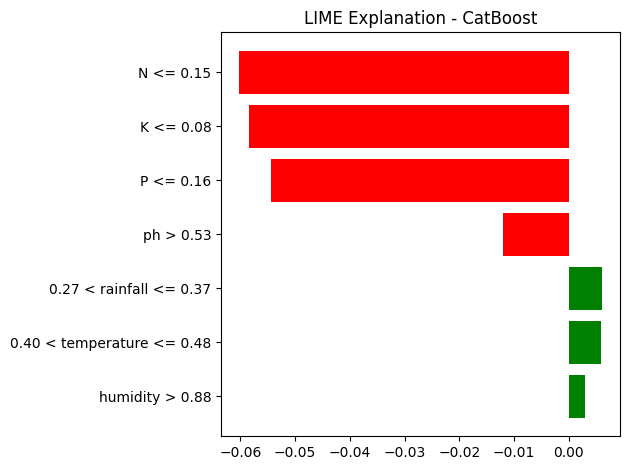


Generating LIME for Stacking...


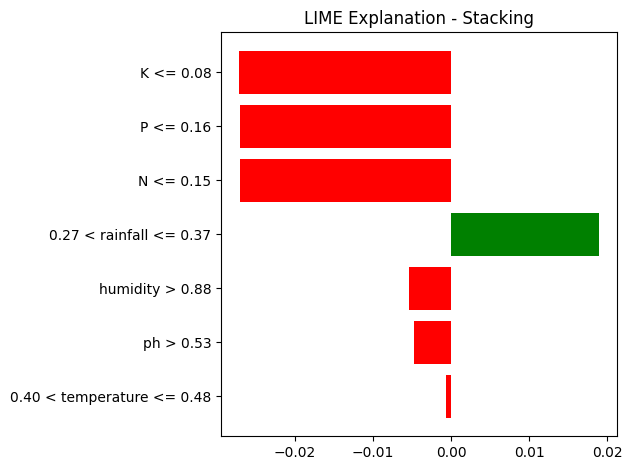

In [58]:
run_lime(rf, "RandomForest")
run_lime(gb, "GradientBoosting")
run_lime(cb, "CatBoost")
run_lime(stack, "Stacking")

In [59]:
!pip install shap

In [60]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Initialize JavaScript for interactive plots (optional)
shap.initjs()

In [61]:
def get_shap_values(model, X):
    """
    Compute SHAP values for a tree-based model.
    Works for multi-class classification.
    """
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    return explainer, shap_values

In [62]:
# Compute SHAP values using the modern __call__ interface to get Explanation objects
rf_explainer = shap.TreeExplainer(rf)
rf_shap = rf_explainer(X_test)

cb_explainer = shap.TreeExplainer(cb)
cb_shap = cb_explainer(X_test)

Plotting Random Forest SHAP...


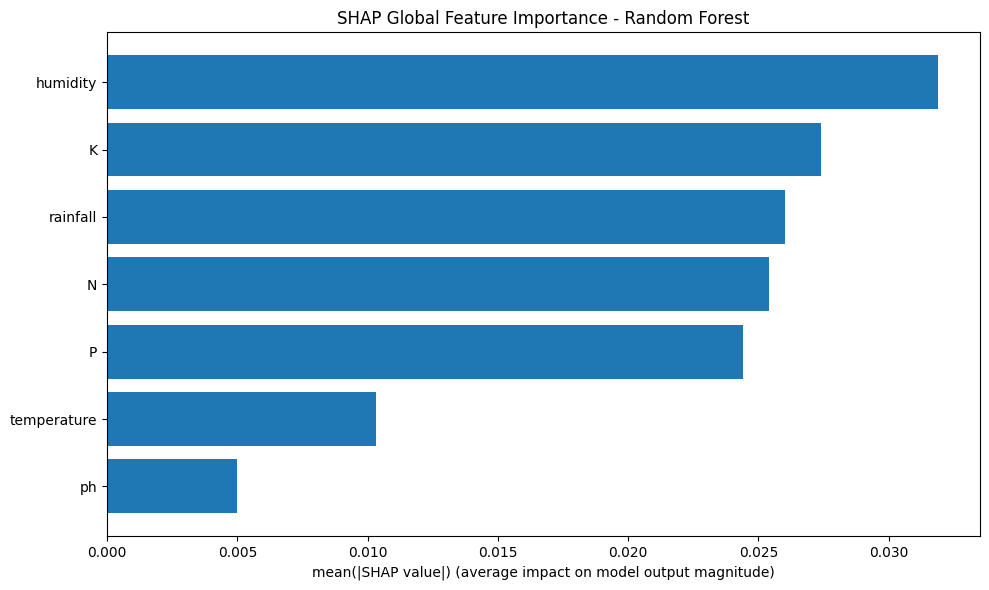

Plotting CatBoost SHAP...


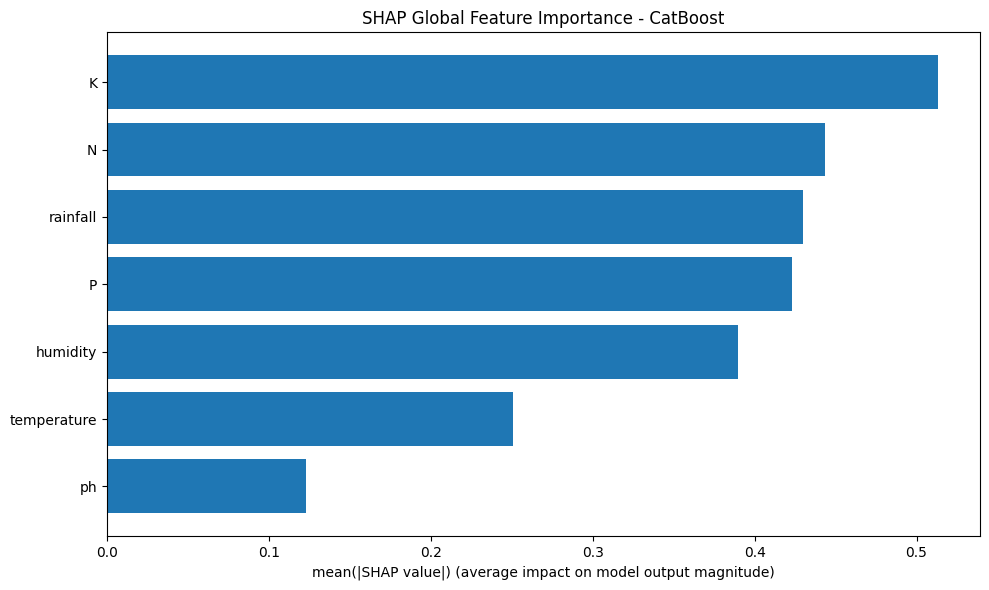

In [63]:
def plot_shap_summary(shap_values, X, model_name):
    # For multi-class, shap_values.values is often (samples, features, classes)
    # We aggregate by taking the mean absolute value across axis 0 (samples) and axis 2 (classes)
    import numpy as np

    vals = shap_values.values
    if len(vals.shape) == 3:
        # Global importance = average across samples and classes
        global_importance = np.abs(vals).mean(axis=(0, 2))
    else:
        global_importance = np.abs(vals).mean(axis=0)

    # Sort features by importance
    indices = np.argsort(global_importance)
    sorted_features = [FEATURES[i] for i in indices]
    sorted_importance = global_importance[indices]

    plt.figure(figsize=(10,6))
    plt.barh(sorted_features, sorted_importance)
    plt.title(f"SHAP Global Feature Importance - {model_name}")
    plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
    plt.tight_layout()
    plt.savefig(f"shap_summary_{model_name}.png", dpi=300)
    plt.show()

# Plotting available SHAP values
print("Plotting Random Forest SHAP...")
plot_shap_summary(rf_shap, X_test, "Random Forest")

print("Plotting CatBoost SHAP...")
plot_shap_summary(cb_shap, X_test, "CatBoost")

Random Forest Feature Importance:


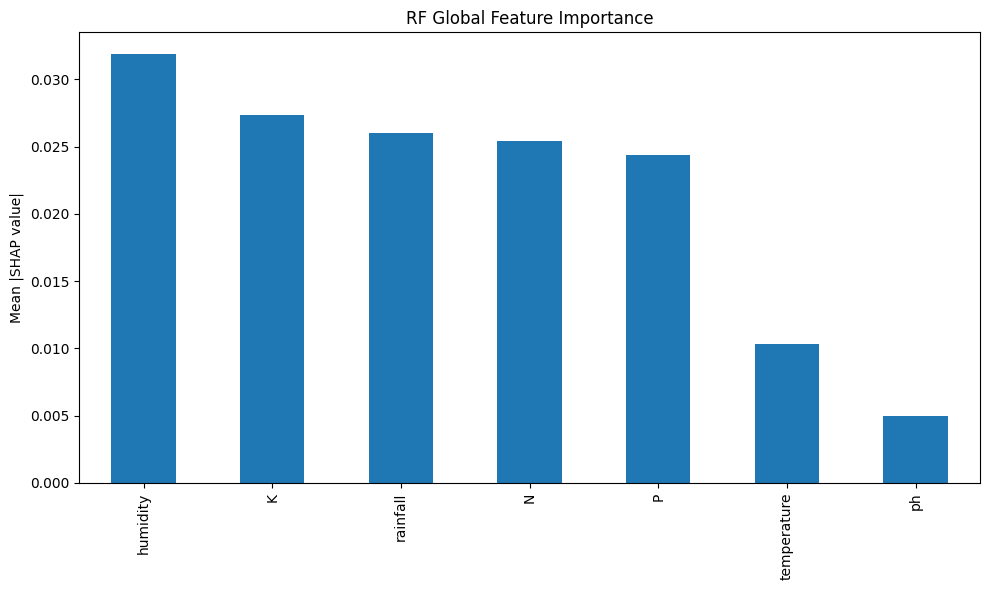

CatBoost Feature Importance:


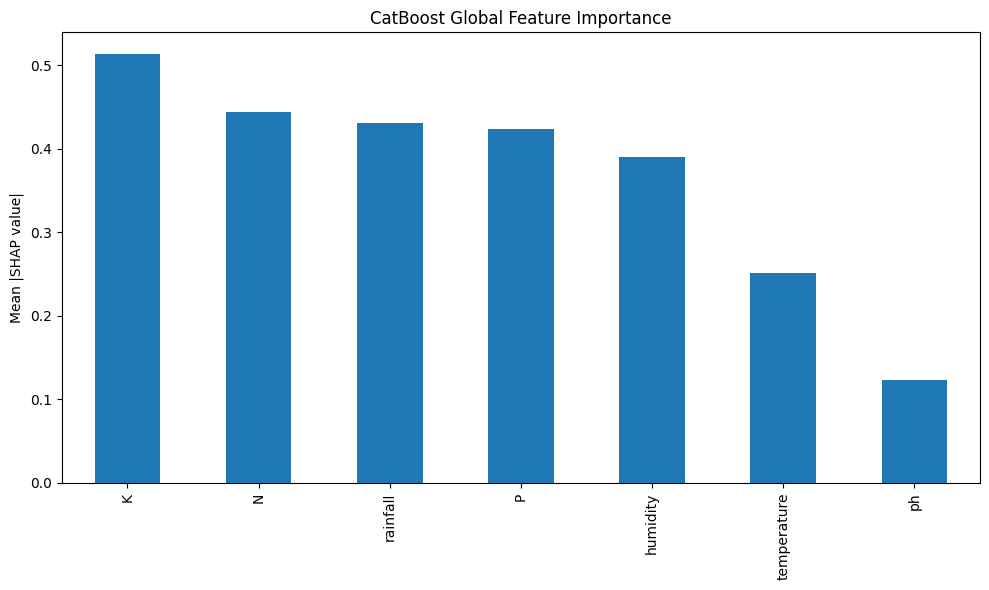

In [64]:
def get_global_importance(explanation, feature_names):
    # explanation.values for multi-class is (samples, features, classes)
    # We take mean absolute value across samples and classes
    import numpy as np
    import pandas as pd

    # Get absolute values
    abs_vals = np.abs(explanation.values)

    # Average over samples (axis 0) and classes (axis 2)
    # If binary/single output, axis 2 might not exist, handle accordingly
    if len(abs_vals.shape) == 3:
        importance = abs_vals.mean(axis=(0, 2))
    else:
        importance = abs_vals.mean(axis=0)

    return pd.Series(importance, index=feature_names).sort_values(ascending=False)

# Calculate importance
rf_imp = get_global_importance(rf_shap, FEATURES)
cb_imp = get_global_importance(cb_shap, FEATURES)

# Plotting manually
def plot_manual_importance(importance_series, title):
    plt.figure(figsize=(10, 6))
    importance_series.plot(kind='bar')
    plt.title(title)
    plt.ylabel('Mean |SHAP value|')
    plt.tight_layout()
    plt.show()

print('Random Forest Feature Importance:')
plot_manual_importance(rf_imp, 'RF Global Feature Importance')

print('CatBoost Feature Importance:')
plot_manual_importance(cb_imp, 'CatBoost Global Feature Importance')

<Figure size 1000x600 with 0 Axes>

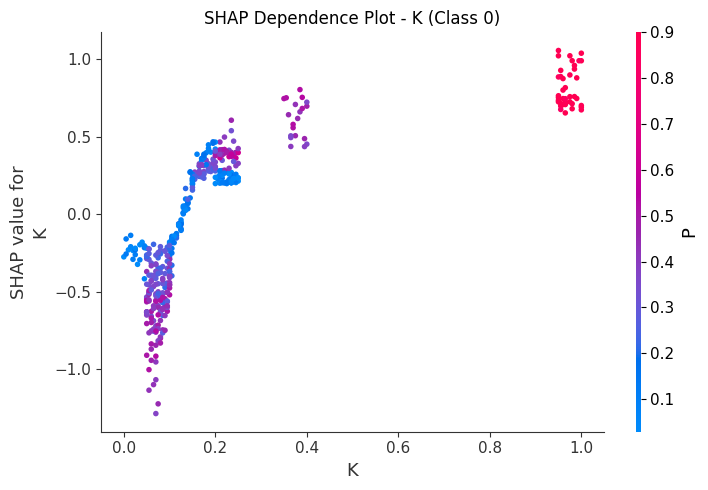

In [65]:
# Get the most important feature from CatBoost results calculated in the previous cell
most_important_feature = cb_imp.index[0]

plt.figure(figsize=(10,6))
# For multi-class, we need to specify which class to plot or pass the specific SHAP values for that feature
# shap.dependence_plot usually expects a matrix of SHAP values.
# For Explanation objects, we index by class. Let's use the first class as an example.
shap.dependence_plot(
    most_important_feature,
    cb_shap.values[:, :, 0], # SHAP values for the first class
    X_test,
    feature_names=FEATURES,
    show=False
)
plt.title(f"SHAP Dependence Plot - {most_important_feature} (Class 0)")
plt.tight_layout()
plt.savefig("shap_dependence_plot.png", dpi=300)
plt.show()

In [66]:
print("===== FEATURE IMPORTANCE CORRELATION =====")
# Comparing RF and CatBoost global importance
correlation = rf_imp.corr(cb_imp)
print(f"RF vs CB Importance Correlation: {correlation:.4f}")

===== FEATURE IMPORTANCE CORRELATION =====
RF vs CB Importance Correlation: 0.9025


In [67]:
print("\n===== TOP 5 FEATURES =====")
print("Random Forest:")
print(rf_imp.sort_values(ascending=False).head(5))

print("\nCatBoost:")
print(cb_imp.sort_values(ascending=False).head(5))


===== TOP 5 FEATURES =====
Random Forest:
humidity    0.031911
K           0.027387
rainfall    0.026016
N           0.025390
P           0.024418
dtype: float64

CatBoost:
K           0.513540
N           0.443340
rainfall    0.430108
P           0.423078
humidity    0.389400
dtype: float64
